In [4]:
import os
import pandas as pd
import numpy as np

PROCESSED_PATH = "../data/processed/ukdale_fundamental_cleaned_6s.h5"

HOUSE_ID = 5
APPLIANCE = "fridge_freezer"

DATA_KEY = f"/house_{HOUSE_ID}/{APPLIANCE}"

print("CO preparation notebook started.")
print("Processed dataset exists:", os.path.exists(PROCESSED_PATH))
print("Selected dataset:", DATA_KEY)

with pd.HDFStore(PROCESSED_PATH, mode="r") as store:
    print("\nDataset available:", DATA_KEY in store.keys())

CO preparation notebook started.
Processed dataset exists: True
Selected dataset: /house_5/fridge_freezer

Dataset available: True


In [5]:
with pd.HDFStore(PROCESSED_PATH, mode="r") as store:
    co_data = store[DATA_KEY]

print("CO dataset loaded successfully.")
print("Rows:", len(co_data))
print("Columns:", list(co_data.columns))

print("\nMissing values:")
print(co_data.isna().sum())

print("\nFirst 5 rows:")
display(co_data.head())

CO dataset loaded successfully.
Rows: 1900820
Columns: ['mains', 'appliance']

Missing values:
mains        0
appliance    0
dtype: int64

First 5 rows:


,mains,appliance
2014-06-29 17:23:48+01:00,695.541687,108.0
2014-06-29 17:23:54+01:00,655.263367,105.0
2014-06-29 17:24:00+01:00,698.506653,107.0
2014-06-29 17:24:06+01:00,701.095032,107.0
2014-06-29 17:24:12+01:00,700.584961,105.0


In [6]:
appliance_power = co_data["appliance"]

print("Appliance power statistics:")
print(appliance_power.describe())

print("\nNumber of unique power values:", appliance_power.nunique())

print("\nSelected percentiles:")
print(
    appliance_power.quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]
    )
)

Appliance power statistics:
count    1.900820e+06
mean     3.906663e+01
std      5.341342e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.070000e+02
max      2.048000e+03
Name: appliance, dtype: float64

Number of unique power values: 494

Selected percentiles:
0.00       0.0
0.01       0.0
0.05       0.0
0.25       0.0
0.50       0.0
0.75     107.0
0.95     112.0
0.99     124.0
1.00    2048.0
Name: appliance, dtype: float64


In [7]:
power_counts = (
    appliance_power
    .round()
    .value_counts()
    .sort_values(ascending=False)
)

print("Top 20 most frequent appliance power levels:")
print(power_counts.head(20))

Top 20 most frequent appliance power levels:
appliance
0.0      1221479
110.0     111468
107.0     103616
108.0     101082
109.0      84392
106.0      78868
105.0      41185
111.0      31442
112.0      21916
104.0      15732
113.0      13784
124.0       9229
114.0       8023
117.0       5342
123.0       5024
115.0       4857
122.0       4748
121.0       4284
103.0       3997
125.0       3555
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans

# Use appliance power values for state extraction
power_values = appliance_power.to_numpy().reshape(-1, 1)

# Learn 3 representative appliance power states
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(power_values)

state_centers = np.sort(kmeans.cluster_centers_.flatten())

print("Representative appliance power states (W):")
for state_id, power in enumerate(state_centers):
    print(f"State {state_id}: {power:.2f} W")

Representative appliance power states (W):
State 0: 0.08 W
State 1: 109.46 W
State 2: 822.03 W


In [9]:
# Determine the upper limit for normal operating-state estimation
upper_limit = appliance_power.quantile(0.99)

normal_power = appliance_power[appliance_power <= upper_limit]

print(f"99th percentile power: {upper_limit:.2f} W")
print(f"Samples used for state estimation: {len(normal_power):,}")
print(f"Samples excluded from state estimation: {len(appliance_power) - len(normal_power):,}")

# Cluster the normal operating range
power_values_normal = normal_power.to_numpy().reshape(-1, 1)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(power_values_normal)

state_centers = np.sort(kmeans.cluster_centers_.flatten())

print("\nRepresentative appliance power states:")
for state_id, power in enumerate(state_centers):
    print(f"State {state_id}: {power:.2f} W")

99th percentile power: 124.00 W
Samples used for state estimation: 1,887,200
Samples excluded from state estimation: 13,620

Representative appliance power states:
State 0: -0.02 W
State 1: 108.08 W
State 2: 119.19 W


In [10]:
HOUSE_ID = 5

CO_APPLIANCES = [
    "fridge_freezer",
    "washer_dryer",
    "electric_oven"
]

house5_data = {}

with pd.HDFStore(PROCESSED_PATH, mode="r") as store:
    for appliance in CO_APPLIANCES:
        key = f"/house_{HOUSE_ID}/{appliance}"
        house5_data[appliance] = store[key]

print("House 5 CO datasets loaded:\n")

for appliance, data in house5_data.items():
    print(
        f"{appliance:20s} | "
        f"rows: {len(data):,} | "
        f"missing: {data.isna().sum().sum()}"
    )

House 5 CO datasets loaded:

fridge_freezer       | rows: 1,900,820 | missing: 0
washer_dryer         | rows: 1,900,814 | missing: 0
electric_oven        | rows: 1,900,727 | missing: 0


In [11]:
# Keep only the appliance columns and rename them
co_appliance_data = pd.concat(
    [
        house5_data["fridge_freezer"]["appliance"].rename("fridge_freezer"),
        house5_data["washer_dryer"]["appliance"].rename("washer_dryer"),
        house5_data["electric_oven"]["appliance"].rename("electric_oven"),
    ],
    axis=1,
    join="inner"
)

# Add the mains signal from the fridge-freezer dataset.
# The mains signal is the same House 5 aggregate measurement.
co_appliance_data.insert(
    0,
    "mains",
    house5_data["fridge_freezer"].loc[
        co_appliance_data.index,
        "mains"
    ]
)

print("Common CO dataset created.")
print("Rows:", len(co_appliance_data))
print("Columns:", list(co_appliance_data.columns))

print("\nMissing values:")
print(co_appliance_data.isna().sum())

print("\nFirst 5 rows:")
display(co_appliance_data.head())

Common CO dataset created.
Rows: 1900725
Columns: ['mains', 'fridge_freezer', 'washer_dryer', 'electric_oven']

Missing values:
mains             0
fridge_freezer    0
washer_dryer      0
electric_oven     0
dtype: int64

First 5 rows:


,mains,fridge_freezer,washer_dryer,electric_oven
2014-06-29 17:23:54+01:00,655.263367,105.0,225.0,0.0
2014-06-29 17:24:00+01:00,698.506653,107.0,262.0,0.0
2014-06-29 17:24:06+01:00,701.095032,107.0,219.0,0.0
2014-06-29 17:24:12+01:00,700.584961,105.0,236.0,0.0
2014-06-29 17:24:18+01:00,704.889954,108.0,231.0,0.0


In [12]:
from sklearn.cluster import KMeans

STATE_COUNT = 3

appliance_states = {}

for appliance in CO_APPLIANCES:
    power = co_appliance_data[appliance]

    upper_limit = power.quantile(0.99)
    normal_power = power[power <= upper_limit]

    kmeans = KMeans(
        n_clusters=STATE_COUNT,
        random_state=42,
        n_init=10
    )

    kmeans.fit(normal_power.to_numpy().reshape(-1, 1))

    centers = np.sort(kmeans.cluster_centers_.flatten())

    appliance_states[appliance] = centers

    print(f"\n{appliance}")
    print(f"99th percentile: {upper_limit:.2f} W")

    for state_id, power_value in enumerate(centers):
        print(f"  State {state_id}: {power_value:.2f} W")


fridge_freezer
99th percentile: 124.00 W
  State 0: -0.04 W
  State 1: 108.06 W
  State 2: 119.19 W

washer_dryer
99th percentile: 1408.00 W
  State 0: 13.25 W
  State 1: 312.39 W
  State 2: 749.41 W

electric_oven
99th percentile: 2104.00 W
  State 0: 3.70 W
  State 1: 114.50 W
  State 2: 2090.32 W


In [13]:
from itertools import product

# Convert tiny negative/near-zero states to exactly zero
for appliance in CO_APPLIANCES:
    appliance_states[appliance][
        np.abs(appliance_states[appliance]) < 1
    ] = 0

# Generate every possible combination of appliance states
state_combinations = list(
    product(
        appliance_states["fridge_freezer"],
        appliance_states["washer_dryer"],
        appliance_states["electric_oven"]
    )
)

print("Number of possible state combinations:", len(state_combinations))

print("\nFirst 10 combinations:")
for combination in state_combinations[:10]:
    print(combination)

Number of possible state combinations: 27

First 10 combinations:
(np.float32(0.0), np.float32(13.2548), np.float32(3.6982303))
(np.float32(0.0), np.float32(13.2548), np.float32(114.4952))
(np.float32(0.0), np.float32(13.2548), np.float32(2090.3162))
(np.float32(0.0), np.float32(312.39154), np.float32(3.6982303))
(np.float32(0.0), np.float32(312.39154), np.float32(114.4952))
(np.float32(0.0), np.float32(312.39154), np.float32(2090.3162))
(np.float32(0.0), np.float32(749.4145), np.float32(3.6982303))
(np.float32(0.0), np.float32(749.4145), np.float32(114.4952))
(np.float32(0.0), np.float32(749.4145), np.float32(2090.3162))
(np.float32(108.060135), np.float32(13.2548), np.float32(3.6982303))


In [14]:
# Convert the combinations into a DataFrame
combination_data = pd.DataFrame(
    state_combinations,
    columns=CO_APPLIANCES
)

# Calculate total power for every possible combination
combination_data["total_power"] = combination_data[
    CO_APPLIANCES
].sum(axis=1)

print("CO state combinations:")
display(combination_data)

print("\nNumber of combinations:", len(combination_data))
print(
    "\nTotal power range:",
    f"{combination_data['total_power'].min():.2f} W",
    "to",
    f"{combination_data['total_power'].max():.2f} W"
)

CO state combinations:


,fridge_freezer,washer_dryer,electric_oven,total_power
0,0.000000,13.254800,3.698230,16.953030
1,0.000000,13.254800,114.495201,127.750000
2,0.000000,13.254800,2090.316162,2103.571045
3,0.000000,312.391541,3.698230,316.089783
4,0.000000,312.391541,114.495201,426.886749
5,0.000000,312.391541,2090.316162,2402.707764
6,0.000000,749.414490,3.698230,753.112732
7,0.000000,749.414490,114.495201,863.909668
8,0.000000,749.414490,2090.316162,2839.730713
9,108.060135,13.254800,3.698230,125.013161



Number of combinations: 27

Total power range: 16.95 W to 2958.92 W


In [15]:
# Convert the combinations into a DataFrame
combination_data = pd.DataFrame(
    state_combinations,
    columns=CO_APPLIANCES
)

# Calculate total power for every possible combination
combination_data["total_power"] = combination_data[
    CO_APPLIANCES
].sum(axis=1)

print("CO state combinations:")
display(combination_data)

print("\nNumber of combinations:", len(combination_data))
print(
    "\nTotal power range:",
    f"{combination_data['total_power'].min():.2f} W",
    "to",
    f"{combination_data['total_power'].max():.2f} W"
)

CO state combinations:


,fridge_freezer,washer_dryer,electric_oven,total_power
0,0.000000,13.254800,3.698230,16.953030
1,0.000000,13.254800,114.495201,127.750000
2,0.000000,13.254800,2090.316162,2103.571045
3,0.000000,312.391541,3.698230,316.089783
4,0.000000,312.391541,114.495201,426.886749
5,0.000000,312.391541,2090.316162,2402.707764
6,0.000000,749.414490,3.698230,753.112732
7,0.000000,749.414490,114.495201,863.909668
8,0.000000,749.414490,2090.316162,2839.730713
9,108.060135,13.254800,3.698230,125.013161



Number of combinations: 27

Total power range: 16.95 W to 2958.92 W


In [16]:
# Convert candidate combination powers to NumPy arrays
combination_powers = combination_data["total_power"].to_numpy()

# Measured aggregate mains power
mains_power = co_appliance_data["mains"].to_numpy()

# Calculate absolute error between mains and every possible combination
errors = np.abs(
    mains_power[:, np.newaxis] - combination_powers[np.newaxis, :]
)

# Select the combination with minimum error for each timestamp
best_combination_indices = np.argmin(errors, axis=1)

# Retrieve the corresponding appliance states
co_estimates = combination_data.iloc[
    best_combination_indices
][CO_APPLIANCES].copy()

# Preserve the original timestamps
co_estimates.index = co_appliance_data.index

# Add measured mains power
co_estimates.insert(
    0,
    "mains",
    co_appliance_data["mains"]
)

print("CO inference completed.")
print("Estimated rows:", len(co_estimates))
print("Columns:", list(co_estimates.columns))

print("\nFirst 5 CO estimates:")
display(co_estimates.head())

CO inference completed.
Estimated rows: 1900725
Columns: ['mains', 'fridge_freezer', 'washer_dryer', 'electric_oven']

First 5 CO estimates:


,mains,fridge_freezer,washer_dryer,electric_oven
2014-06-29 17:23:54+01:00,655.263367,0.0,749.41449,3.69823
2014-06-29 17:24:00+01:00,698.506653,0.0,749.41449,3.69823
2014-06-29 17:24:06+01:00,701.095032,0.0,749.41449,3.69823
2014-06-29 17:24:12+01:00,700.584961,0.0,749.41449,3.69823
2014-06-29 17:24:18+01:00,704.889954,0.0,749.41449,3.69823


In [17]:
# Chronological train/test split
TRAIN_RATIO = 0.80

split_index = int(len(co_appliance_data) * TRAIN_RATIO)

co_train = co_appliance_data.iloc[:split_index].copy()
co_test = co_appliance_data.iloc[split_index:].copy()

print("Chronological train/test split created.")
print()
print("Total samples :", len(co_appliance_data))
print("Training samples:", len(co_train))
print("Testing samples :", len(co_test))

print("\nTraining period:")
print(co_train.index[0], "to", co_train.index[-1])

print("\nTesting period:")
print(co_test.index[0], "to", co_test.index[-1])

Chronological train/test split created.

Total samples : 1900725
Training samples: 1520580
Testing samples : 380145

Training period:
2014-06-29 17:23:54+01:00 to 2014-10-13 17:07:12+01:00

Testing period:
2014-10-13 17:07:18+01:00 to 2014-11-13 17:48:42+00:00


In [18]:
from sklearn.cluster import KMeans

STATE_COUNT = 3

train_appliance_states = {}

for appliance in CO_APPLIANCES:
    power = co_train[appliance]

    # Exclude extreme values only while learning representative states
    upper_limit = power.quantile(0.99)
    normal_power = power[power <= upper_limit]

    kmeans = KMeans(
        n_clusters=STATE_COUNT,
        random_state=42,
        n_init=10
    )

    kmeans.fit(
        normal_power.to_numpy().reshape(-1, 1)
    )

    centers = np.sort(
        kmeans.cluster_centers_.flatten()
    )

    # Treat values extremely close to zero as the OFF state
    centers[np.abs(centers) < 1] = 0

    train_appliance_states[appliance] = centers

    print(f"\n{appliance}")
    print(f"Training 99th percentile: {upper_limit:.2f} W")

    for state_id, power_value in enumerate(centers):
        print(f"  State {state_id}: {power_value:.2f} W")


fridge_freezer
Training 99th percentile: 124.00 W
  State 0: 0.00 W
  State 1: 108.58 W
  State 2: 120.08 W

washer_dryer
Training 99th percentile: 1396.00 W
  State 0: 12.55 W
  State 1: 287.96 W
  State 2: 694.71 W

electric_oven
Training 99th percentile: 2102.00 W
  State 0: 3.00 W
  State 1: 114.29 W
  State 2: 2085.88 W


In [19]:
from itertools import product

state_combinations = list(
    product(
        train_appliance_states["fridge_freezer"],
        train_appliance_states["washer_dryer"],
        train_appliance_states["electric_oven"]
    )
)

combination_data = pd.DataFrame(
    state_combinations,
    columns=CO_APPLIANCES
)

combination_data["total_power"] = combination_data[
    CO_APPLIANCES
].sum(axis=1)

print("CO state combinations generated.")
print("Number of possible combinations:", len(combination_data))

print("\nCombination table:")
display(combination_data)

print(
    "\nTotal combination power range:",
    f"{combination_data['total_power'].min():.2f} W",
    "to",
    f"{combination_data['total_power'].max():.2f} W"
)

CO state combinations generated.
Number of possible combinations: 27

Combination table:


,fridge_freezer,washer_dryer,electric_oven,total_power
0,0.000000,12.553549,3.003443,15.556992
1,0.000000,12.553549,114.285217,126.838768
2,0.000000,12.553549,2085.883789,2098.437256
3,0.000000,287.955597,3.003443,290.959045
4,0.000000,287.955597,114.285217,402.240814
5,0.000000,287.955597,2085.883789,2373.839355
6,0.000000,694.714478,3.003443,697.717896
7,0.000000,694.714478,114.285217,808.999695
8,0.000000,694.714478,2085.883789,2780.598145
9,108.584740,12.553549,3.003443,124.141731



Total combination power range: 15.56 W to 2900.67 W


In [20]:
# CO inference on the test set
combination_powers = combination_data["total_power"].to_numpy()
test_mains = co_test["mains"].to_numpy()

CHUNK_SIZE = 100000

best_indices = []

for start in range(0, len(test_mains), CHUNK_SIZE):
    end = min(start + CHUNK_SIZE, len(test_mains))

    mains_chunk = test_mains[start:end]

    # Compare each mains value with all 27 possible combinations
    errors = np.abs(
        mains_chunk[:, np.newaxis]
        - combination_powers[np.newaxis, :]
    )

    chunk_best_indices = np.argmin(errors, axis=1)
    best_indices.append(chunk_best_indices)

    print(f"Processed samples {start:,} to {end:,}")

best_combination_indices = np.concatenate(best_indices)

# Retrieve estimated appliance states
co_test_estimates = combination_data.iloc[
    best_combination_indices
][CO_APPLIANCES].copy()

# Preserve test timestamps
co_test_estimates.index = co_test.index

# Add measured mains
co_test_estimates.insert(
    0,
    "mains",
    co_test["mains"]
)

print("\nCO test inference completed.")
print("Estimated test rows:", len(co_test_estimates))

print("\nColumns:")
print(list(co_test_estimates.columns))

print("\nFirst 5 test estimates:")
display(co_test_estimates.head())

Processed samples 0 to 100,000
Processed samples 100,000 to 200,000
Processed samples 200,000 to 300,000
Processed samples 300,000 to 380,145

CO test inference completed.
Estimated test rows: 380145

Columns:
['mains', 'fridge_freezer', 'washer_dryer', 'electric_oven']

First 5 test estimates:


,mains,fridge_freezer,washer_dryer,electric_oven
2014-10-13 17:07:18+01:00,730.878357,0.0,694.714478,3.003443
2014-10-13 17:07:24+01:00,696.061707,0.0,694.714478,3.003443
2014-10-13 17:07:30+01:00,733.541687,0.0,694.714478,3.003443
2014-10-13 17:07:36+01:00,737.701660,0.0,694.714478,3.003443
2014-10-13 17:07:42+01:00,732.489990,0.0,694.714478,3.003443


In [21]:
# CO experiment configuration for all selected houses

CO_HOUSES = [1, 2, 5]

CO_APPLIANCES_BY_HOUSE = {
    1: [
        "dishwasher",
        "television",
        "fridge_freezer",
        "microwave",
        "oven"
    ],
    2: [
        "kettle",
        "rice_cooker",
        "washing_machine",
        "dishwasher",
        "fridge"
    ],
    5: [
        "fridge_freezer",
        "washer_dryer",
        "electric_oven"
    ]
}

TRAIN_RATIO = 0.80
STATE_COUNT = 3
CHUNK_SIZE = 100000

print("CO experiment configuration ready.")
print("Houses:", CO_HOUSES)

for house_id in CO_HOUSES:
    print(
        f"House {house_id}: "
        f"{len(CO_APPLIANCES_BY_HOUSE[house_id])} appliances"
    )

print("\nTrain ratio:", TRAIN_RATIO)
print("States per appliance:", STATE_COUNT)
print("Inference chunk size:", CHUNK_SIZE)

CO experiment configuration ready.
Houses: [1, 2, 5]
House 1: 5 appliances
House 2: 5 appliances
House 5: 3 appliances

Train ratio: 0.8
States per appliance: 3
Inference chunk size: 100000


In [22]:
co_house_data = {}

with pd.HDFStore(PROCESSED_PATH, mode="r") as store:
    for house_id in CO_HOUSES:
        co_house_data[house_id] = {}
        
        for appliance in CO_APPLIANCES_BY_HOUSE[house_id]:
            key = f"/house_{house_id}/{appliance}"
            
            co_house_data[house_id][appliance] = store[key]

print("CO datasets loaded successfully.\n")

for house_id in CO_HOUSES:
    print(f"House {house_id}:")
    
    for appliance, data in co_house_data[house_id].items():
        print(
            f"  {appliance:20s} | "
            f"rows: {len(data):,} | "
            f"missing: {data.isna().sum().sum()}"
        )
    
    print()

CO datasets loaded successfully.

House 1:
  dishwasher           | rows: 21,218,580 | missing: 0
  television           | rows: 21,216,359 | missing: 0
  fridge_freezer       | rows: 21,214,063 | missing: 0
  microwave            | rows: 21,214,848 | missing: 0
  oven                 | rows: 20,874,753 | missing: 0

House 2:
  kettle               | rows: 1,931,950 | missing: 0
  rice_cooker          | rows: 1,931,035 | missing: 0
  washing_machine      | rows: 1,513,870 | missing: 0
  dishwasher           | rows: 1,513,926 | missing: 0
  fridge               | rows: 1,513,927 | missing: 0

House 5:
  fridge_freezer       | rows: 1,900,820 | missing: 0
  washer_dryer         | rows: 1,900,814 | missing: 0
  electric_oven        | rows: 1,900,727 | missing: 0



In [23]:
co_aligned_data = {}

for house_id in CO_HOUSES:
    appliances = CO_APPLIANCES_BY_HOUSE[house_id]
    
    # Start with the first appliance's data
    first_appliance = appliances[0]
    
    aligned = co_house_data[house_id][first_appliance][
        ["mains", "appliance"]
    ].rename(
        columns={"appliance": first_appliance}
    )
    
    # Add the remaining appliances using common timestamps
    for appliance in appliances[1:]:
        appliance_series = (
            co_house_data[house_id][appliance]["appliance"]
            .rename(appliance)
        )
        
        aligned = aligned.join(
            appliance_series,
            how="inner"
        )
    
    co_aligned_data[house_id] = aligned
    
    print(f"House {house_id}:")
    print("  Rows:", f"{len(aligned):,}")
    print("  Columns:", list(aligned.columns))
    print("  Missing values:", aligned.isna().sum().sum())
    print()

House 1:
  Rows: 20,856,203
  Columns: ['mains', 'dishwasher', 'television', 'fridge_freezer', 'microwave', 'oven']
  Missing values: 0

House 2:
  Rows: 1,512,957
  Columns: ['mains', 'kettle', 'rice_cooker', 'washing_machine', 'dishwasher', 'fridge']
  Missing values: 0

House 5:
  Rows: 1,900,725
  Columns: ['mains', 'fridge_freezer', 'washer_dryer', 'electric_oven']
  Missing values: 0



In [24]:
co_train_data = {}
co_test_data = {}

for house_id in CO_HOUSES:
    data = co_aligned_data[house_id]
    
    split_index = int(len(data) * TRAIN_RATIO)
    
    co_train_data[house_id] = data.iloc[:split_index].copy()
    co_test_data[house_id] = data.iloc[split_index:].copy()
    
    print(f"House {house_id}:")
    print(f"  Total samples : {len(data):,}")
    print(f"  Training samples: {len(co_train_data[house_id]):,}")
    print(f"  Testing samples : {len(co_test_data[house_id]):,}")
    
    print(
        f"  Training period: "
        f"{data.index[0]} → "
        f"{co_train_data[house_id].index[-1]}"
    )
    
    print(
        f"  Testing period : "
        f"{co_test_data[house_id].index[0]} → "
        f"{data.index[-1]}"
    )
    
    print()

House 1:
  Total samples : 20,856,203
  Training samples: 16,684,962
  Testing samples : 4,171,241
  Training period: 2013-03-17 19:12:42+00:00 → 2016-06-26 05:44:06+01:00
  Testing period : 2016-06-26 05:44:12+01:00 → 2017-04-26 18:32:48+01:00

House 2:
  Total samples : 1,512,957
  Training samples: 1,210,365
  Testing samples : 302,592
  Training period: 2013-05-20 22:28:36+01:00 → 2013-09-19 04:24:48+01:00
  Testing period : 2013-09-19 04:24:54+01:00 → 2013-10-10 06:15:18+01:00

House 5:
  Total samples : 1,900,725
  Training samples: 1,520,580
  Testing samples : 380,145
  Training period: 2014-06-29 17:23:54+01:00 → 2014-10-13 17:07:12+01:00
  Testing period : 2014-10-13 17:07:18+01:00 → 2014-11-13 17:48:42+00:00



In [25]:
from sklearn.cluster import KMeans

train_states_by_house = {}

for house_id in CO_HOUSES:
    train_states_by_house[house_id] = {}
    
    print(f"\n{'=' * 60}")
    print(f"House {house_id}")
    print(f"{'=' * 60}")
    
    for appliance in CO_APPLIANCES_BY_HOUSE[house_id]:
        power = co_train_data[house_id][appliance]
        
        # Remove extreme values only during state learning
        upper_limit = power.quantile(0.99)
        normal_power = power[power <= upper_limit]
        
        kmeans = KMeans(
            n_clusters=STATE_COUNT,
            random_state=42,
            n_init=10
        )
        
        kmeans.fit(
            normal_power.to_numpy().reshape(-1, 1)
        )
        
        centers = np.sort(
            kmeans.cluster_centers_.flatten()
        )
        
        # Treat very small values as the OFF state
        centers[np.abs(centers) < 1] = 0
        
        train_states_by_house[house_id][appliance] = centers
        
        print(f"\n{appliance}")
        print(f"  Training 99th percentile: {upper_limit:.2f} W")
        
        for state_id, power_value in enumerate(centers):
            print(
                f"  State {state_id}: "
                f"{power_value:.2f} W"
            )


House 1

dishwasher
  Training 99th percentile: 122.00 W
  State 0: 0.00 W
  State 1: 27.80 W
  State 2: 119.01 W

television
  Training 99th percentile: 129.00 W
  State 0: 0.00 W
  State 1: 95.20 W
  State 2: 117.71 W

fridge_freezer
  Training 99th percentile: 246.00 W
  State 0: 0.00 W
  State 1: 89.44 W
  State 2: 238.66 W

microwave
  Training 99th percentile: 1.00 W
  State 0: 0.00 W
  State 1: 0.00 W
  State 2: 1.00 W

oven
  Training 99th percentile: 46.00 W
  State 0: 2.99 W
  State 1: 14.35 W
  State 2: 45.56 W

House 2

kettle
  Training 99th percentile: 1.00 W
  State 0: 0.00 W
  State 1: 0.00 W
  State 2: 0.00 W

rice_cooker
  Training 99th percentile: 1.00 W
  State 0: 0.00 W
  State 1: 0.00 W
  State 2: 0.00 W

washing_machine
  Training 99th percentile: 71.00 W
  State 0: 3.14 W
  State 1: 23.40 W
  State 2: 57.40 W

dishwasher
  Training 99th percentile: 1996.00 W
  State 0: 0.00 W
  State 1: 103.71 W
  State 2: 1968.90 W

fridge
  Training 99th percentile: 100.00 W


In [26]:
print("Learned CO states:\n")

for house_id in CO_HOUSES:
    print(f"\nHouse {house_id}")
    
    for appliance in CO_APPLIANCES_BY_HOUSE[house_id]:
        states = train_states_by_house[house_id][appliance]
        
        print(
            f"  {appliance:20s}: "
            + ", ".join(f"{value:.2f} W" for value in states)
        )

Learned CO states:


House 1
  dishwasher          : 0.00 W, 27.80 W, 119.01 W
  television          : 0.00 W, 95.20 W, 117.71 W
  fridge_freezer      : 0.00 W, 89.44 W, 238.66 W
  microwave           : 0.00 W, 0.00 W, 1.00 W
  oven                : 2.99 W, 14.35 W, 45.56 W

House 2
  kettle              : 0.00 W, 0.00 W, 0.00 W
  rice_cooker         : 0.00 W, 0.00 W, 0.00 W
  washing_machine     : 3.14 W, 23.40 W, 57.40 W
  dishwasher          : 0.00 W, 103.71 W, 1968.90 W
  fridge              : 10.64 W, 85.03 W, 93.86 W

House 5
  fridge_freezer      : 0.00 W, 108.58 W, 120.08 W
  washer_dryer        : 12.55 W, 287.96 W, 694.71 W
  electric_oven       : 3.00 W, 114.29 W, 2085.88 W


In [27]:
PROBLEMATIC_APPLIANCES = {
    1: ["microwave"],
    2: ["kettle", "rice_cooker"]
}

print("Non-zero training power statistics:\n")

for house_id, appliances in PROBLEMATIC_APPLIANCES.items():
    print(f"\n{'=' * 50}")
    print(f"House {house_id}")
    print(f"{'=' * 50}")
    
    for appliance in appliances:
        power = co_train_data[house_id][appliance]
        non_zero = power[power > 0]
        
        print(f"\n{appliance}")
        print(f"  Total samples : {len(power):,}")
        print(f"  Non-zero samples: {len(non_zero):,}")
        
        if len(non_zero) > 0:
            print(f"  Non-zero percentage: {len(non_zero) / len(power) * 100:.4f}%")
            print(f"  Minimum: {non_zero.min():.2f} W")
            print(f"  Median : {non_zero.median():.2f} W")
            print(f"  95th percentile: {non_zero.quantile(0.95):.2f} W")
            print(f"  Maximum: {non_zero.max():.2f} W")

Non-zero training power statistics:


House 1

microwave
  Total samples : 16,684,962
  Non-zero samples: 16,560,741
  Non-zero percentage: 99.2555%
  Minimum: 0.02 W
  Median : 1.00 W
  95th percentile: 1.00 W
  Maximum: 3267.00 W

House 2

kettle
  Total samples : 1,210,365
  Non-zero samples: 1,185,412
  Non-zero percentage: 97.9384%
  Minimum: 0.50 W
  Median : 1.00 W
  95th percentile: 1.00 W
  Maximum: 3996.00 W

rice_cooker
  Total samples : 1,210,365
  Non-zero samples: 1,205,352
  Non-zero percentage: 99.5858%
  Minimum: 0.50 W
  Median : 1.00 W
  95th percentile: 1.00 W
  Maximum: 821.00 W


In [28]:
print("Detailed non-zero training statistics:\n")

for house_id in PROBLEMATIC_APPLIANCES:
    print(f"\nHouse {house_id}")
    
    for appliance in PROBLEMATIC_APPLIANCES[house_id]:
        power = co_train_data[house_id][appliance]
        non_zero = power[power > 0]
        
        print(
            f"{appliance:15s} | "
            f"non-zero: {len(non_zero):,} "
            f"({len(non_zero) / len(power) * 100:.2f}%) | "
            f"median: {non_zero.median():.2f} W | "
            f"95%: {non_zero.quantile(0.95):.2f} W | "
            f"99%: {non_zero.quantile(0.99):.2f} W | "
            f"max: {non_zero.max():.2f} W"
        )

Detailed non-zero training statistics:


House 1
microwave       | non-zero: 16,560,741 (99.26%) | median: 1.00 W | 95%: 1.00 W | 99%: 1.00 W | max: 3267.00 W

House 2
kettle          | non-zero: 1,185,412 (97.94%) | median: 1.00 W | 95%: 1.00 W | 99%: 1.00 W | max: 3996.00 W
rice_cooker     | non-zero: 1,205,352 (99.59%) | median: 1.00 W | 95%: 1.00 W | 99%: 1.00 W | max: 821.00 W


In [29]:
print("Most frequent power levels in training data:\n")

for house_id, appliances in PROBLEMATIC_APPLIANCES.items():
    print(f"\n{'=' * 55}")
    print(f"House {house_id}")
    print(f"{'=' * 55}")
    
    for appliance in appliances:
        power = co_train_data[house_id][appliance]
        
        rounded_power = power.round(0)
        counts = rounded_power.value_counts().head(15)
        
        print(f"\n{appliance}")
        print("Power (W) | Count")
        
        for power_value, count in counts.items():
            print(f"{power_value:9.0f} | {count:,}")

Most frequent power levels in training data:


House 1

microwave
Power (W) | Count
        1 | 16,442,147
        0 | 124,321
        3 | 9,252
       49 | 2,262
        2 | 1,944
       48 | 1,802
       50 | 1,320
       21 | 1,014
     1594 | 755
     1584 | 745
     1592 | 730
     1580 | 726
     1590 | 725
     1586 | 715
     1588 | 708

House 2

kettle
Power (W) | Count
        1 | 1,175,059
        0 | 24,966
        2 | 653
     2961 | 104
     2933 | 104
     2928 | 101
     2957 | 100
     2967 | 97
     2939 | 96
     2948 | 95
     2945 | 92
     2954 | 92
     2964 | 90
     2942 | 87
     2971 | 85

rice_cooker
Power (W) | Count
        1 | 1,195,693
        0 | 5,021
       39 | 1,659
       38 | 1,072
        2 | 689
       40 | 544
      403 | 356
      402 | 325
      404 | 301
      407 | 298
      406 | 292
      405 | 289
      401 | 288
      400 | 273
      408 | 250


In [30]:
print("CO appliance power distribution summary")
print("=" * 75)

for house_id in CO_HOUSES:
    print(f"\n{'=' * 75}")
    print(f"House {house_id}")
    print(f"{'=' * 75}")

    for appliance in CO_APPLIANCES_BY_HOUSE[house_id]:
        power = co_train_data[house_id][appliance]

        non_zero = power[power > 1]

        print(f"\n{appliance}")
        print(f"Total samples       : {len(power):,}")
        print(f"Power > 1 W samples : {len(non_zero):,} "
              f"({len(non_zero) / len(power) * 100:.2f}%)")

        if len(non_zero) > 0:
            print(
                f"Non-zero/high-power quantiles (W): "
                f"P25={non_zero.quantile(0.25):.2f}, "
                f"P50={non_zero.quantile(0.50):.2f}, "
                f"P75={non_zero.quantile(0.75):.2f}, "
                f"P90={non_zero.quantile(0.90):.2f}, "
                f"P95={non_zero.quantile(0.95):.2f}, "
                f"P99={non_zero.quantile(0.99):.2f}"
            )

            print(f"Maximum power      : {non_zero.max():.2f} W")
        else:
            print("No samples above 1 W.")

CO appliance power distribution summary

House 1

dishwasher
Total samples       : 16,684,962
Power > 1 W samples : 427,211 (2.56%)
Non-zero/high-power quantiles (W): P25=118.00, P50=121.00, P75=2310.00, P90=2348.00, P95=2364.00, P99=2393.00
Maximum power      : 3973.00 W

television
Total samples       : 16,684,962
Power > 1 W samples : 1,744,109 (10.45%)
Non-zero/high-power quantiles (W): P25=94.00, P50=102.00, P75=116.00, P90=129.00, P95=130.00, P99=133.00
Maximum power      : 1542.00 W

fridge_freezer
Total samples       : 16,684,962
Power > 1 W samples : 7,140,558 (42.80%)
Non-zero/high-power quantiles (W): P25=87.00, P50=89.00, P75=92.00, P90=96.00, P95=103.00, P99=250.00
Maximum power      : 3323.00 W

microwave
Total samples       : 16,684,962
Power > 1 W samples : 118,494 (0.71%)
Non-zero/high-power quantiles (W): P25=260.00, P50=1496.00, P75=1579.00, P90=1606.00, P95=1618.00, P99=1640.00
Maximum power      : 3267.00 W

oven
Total samples       : 16,684,962
Power > 1 W samples

In [31]:
from sklearn.cluster import KMeans

ON_THRESHOLD = 1.0
MAX_ON_STATES = 3

state_candidates = {}

print("Evaluating number of meaningful ON states")
print("=" * 75)

for house_id in CO_HOUSES:
    state_candidates[house_id] = {}

    print(f"\n{'=' * 75}")
    print(f"House {house_id}")
    print(f"{'=' * 75}")

    for appliance in CO_APPLIANCES_BY_HOUSE[house_id]:

        power = co_train_data[house_id][appliance]

        # Keep only meaningful ON/high-power samples
        on_power = power[power > ON_THRESHOLD].to_numpy()

        print(f"\n{appliance}")
        print(f"ON samples (> {ON_THRESHOLD} W): {len(on_power):,}")

        state_candidates[house_id][appliance] = {}

        if len(on_power) == 0:
            print("No ON samples found.")
            continue

        for n_states in range(1, MAX_ON_STATES + 1):

            # Avoid asking for more clusters than available samples
            if len(on_power) < n_states:
                continue

            kmeans = KMeans(
                n_clusters=n_states,
                random_state=42,
                n_init=10
            )

            labels = kmeans.fit_predict(
                on_power.reshape(-1, 1)
            )

            centers = np.sort(
                kmeans.cluster_centers_.flatten()
            )

            # Calculate mean absolute distance from each sample
            # to its assigned cluster center
            distances = np.abs(
                on_power - kmeans.cluster_centers_.flatten()[labels]
            )

            mae = distances.mean()

            state_candidates[house_id][appliance][n_states] = {
                "centers": centers,
                "mae": mae
            }

            print(
                f"{n_states} ON state(s): "
                f"MAE={mae:.2f} W | "
                f"centers={np.round(centers, 2)}"
            )

Evaluating number of meaningful ON states

House 1

dishwasher
ON samples (> 1.0 W): 427,211
1 ON state(s): MAE=1005.15 W | centers=[869.84]
2 ON state(s): MAE=28.14 W | centers=[ 104.12 2331.67]
3 ON state(s): MAE=12.73 W | centers=[  13.87  120.14 2331.67]

television
ON samples (> 1.0 W): 1,744,109
1 ON state(s): MAE=12.63 W | centers=[105.09]
2 ON state(s): MAE=6.60 W | centers=[ 95.61 122.45]
3 ON state(s): MAE=6.49 W | centers=[  95.21  121.46 1199.48]

fridge_freezer
ON samples (> 1.0 W): 7,140,558
1 ON state(s): MAE=11.50 W | centers=[94.48]
2 ON state(s): MAE=4.98 W | centers=[ 89.1  268.14]
3 ON state(s): MAE=4.23 W | centers=[  89.08  253.53 1544.95]

microwave
ON samples (> 1.0 W): 118,494
1 ON state(s): MAE=571.09 W | centers=[1132.07]
2 ON state(s): MAE=88.07 W | centers=[  91.63 1524.31]
3 ON state(s): MAE=58.43 W | centers=[  88.08 1377.76 1580.22]

oven
ON samples (> 1.0 W): 16,684,906
1 ON state(s): MAE=1.49 W | centers=[3.76]
2 ON state(s): MAE=0.16 W | centers=[ 3.0

In [33]:
print("ON-event duration analysis")
print("=" * 75)

ON_THRESHOLD = 1.0
SAMPLE_PERIOD = 6  # UK-DALE working sampling interval

for house_id in CO_HOUSES:
    print(f"\n{'=' * 75}")
    print(f"House {house_id}")
    print(f"{'=' * 75}")

    for appliance in CO_APPLIANCES_BY_HOUSE[house_id]:

        power = co_train_data[house_id][appliance]

        # Identify samples where appliance is meaningfully ON
        is_on = power > ON_THRESHOLD

        # Identify consecutive ON runs
        groups = (is_on != is_on.shift()).cumsum()
        on_lengths = is_on[is_on].groupby(groups[is_on]).size()

        if len(on_lengths) == 0:
            print(f"\n{appliance}: No ON events.")
            continue

        # Convert number of samples to seconds
        duration_seconds = on_lengths * SAMPLE_PERIOD

        print(f"\n{appliance}")
        print(f"Number of ON events : {len(duration_seconds):,}")

        print(
            f"Duration (seconds): "
            f"P25={duration_seconds.quantile(0.25):.0f}, "
            f"P50={duration_seconds.quantile(0.50):.0f}, "
            f"P75={duration_seconds.quantile(0.75):.0f}, "
            f"P90={duration_seconds.quantile(0.90):.0f}"
        )

        print(
            f"Minimum={duration_seconds.min():.0f}s, "
            f"Maximum={duration_seconds.max():.0f}s"
        )

ON-event duration analysis

House 1

dishwasher
Number of ON events : 5,833
Duration (seconds): P25=6, P50=12, P75=18, P90=1008
Minimum=6s, Maximum=6216s

television
Number of ON events : 5,752
Duration (seconds): P25=12, P50=12, P75=1328, P90=7998
Minimum=6s, Maximum=48330s

fridge_freezer
Number of ON events : 52,500
Duration (seconds): P25=12, P50=624, P75=1596, P90=2082
Minimum=6s, Maximum=22626s

microwave
Number of ON events : 14,455
Duration (seconds): P25=6, P50=18, P75=54, P90=96
Minimum=6s, Maximum=1248s

oven
Number of ON events : 32
Duration (seconds): P25=567954, P50=2191356, P75=4518642, P90=6121964
Minimum=90s, Maximum=15933720s

House 2

kettle
Number of ON events : 684
Duration (seconds): P25=12, P50=63, P75=174, P90=198
Minimum=6s, Maximum=246s

rice_cooker
Number of ON events : 357
Duration (seconds): P25=12, P50=12, P75=12, P90=18
Minimum=6s, Maximum=2976s

washing_machine
Number of ON events : 616
Duration (seconds): P25=24, P50=66, P75=192, P90=639
Minimum=6s, Max

In [34]:
print("Low-power distribution diagnostic")
print("=" * 75)

for house_id in CO_HOUSES:
    print(f"\n{'=' * 75}")
    print(f"House {house_id}")
    print(f"{'=' * 75}")

    for appliance in CO_APPLIANCES_BY_HOUSE[house_id]:

        power = co_train_data[house_id][appliance]

        # Round to nearest watt and inspect values up to 50 W
        low_power = power[power <= 50].round(0)
        counts = low_power.value_counts().sort_index()

        print(f"\n{appliance}")
        print("Power (W) | Count")

        for power_value, count in counts.items():
            print(f"{power_value:9.0f} | {count:,}")

Low-power distribution diagnostic

House 1

dishwasher
Power (W) | Count
        0 | 2,798,130
        1 | 13,459,621
        2 | 7,930
        3 | 64
        4 | 4
        5 | 6
        6 | 14,745
        7 | 1,466
        8 | 363
        9 | 52
       10 | 812
       11 | 258
       12 | 85
       13 | 43
       14 | 16
       15 | 24
       16 | 35
       17 | 21
       18 | 14
       19 | 16
       20 | 17
       21 | 9
       22 | 40
       23 | 223
       24 | 1,886
       25 | 5,004
       26 | 3,952
       27 | 1,019
       28 | 319
       29 | 244
       30 | 173
       31 | 177
       32 | 234
       33 | 481
       34 | 434
       35 | 221
       36 | 299
       37 | 858
       38 | 518
       39 | 58
       40 | 40
       41 | 27
       42 | 13
       43 | 29
       44 | 25
       45 | 13
       46 | 8
       47 | 15
       48 | 11
       49 | 10
       50 | 9

television
Power (W) | Count
        0 | 391,648
        1 | 14,549,205
        2 | 8,449
        3 | 48
        4

In [35]:
from sklearn.cluster import KMeans

STATE_COUNT = 3
BACKGROUND_THRESHOLD = 1.0

final_co_states = {}

print("Final CO appliance state models")
print("=" * 75)

for house_id in CO_HOUSES:

    final_co_states[house_id] = {}

    print(f"\n{'=' * 75}")
    print(f"House {house_id}")
    print(f"{'=' * 75}")

    for appliance in CO_APPLIANCES_BY_HOUSE[house_id]:

        power = co_train_data[house_id][appliance]

        # Identify the dominant 0/1 W measurement floor.
        zero_count = (power == 0).sum()
        one_count = (power == 1).sum()

        # Remove exact 0 W and 1 W values from state learning.
        # These are treated as background/measurement-floor values.
        state_learning_power = power[
            (power > BACKGROUND_THRESHOLD)
        ].to_numpy()

        if len(state_learning_power) == 0:

            states = np.array([0.0])

        else:

            n_clusters = min(
                STATE_COUNT,
                len(state_learning_power)
            )

            kmeans = KMeans(
                n_clusters=n_clusters,
                random_state=42,
                n_init=10
            )

            kmeans.fit(
                state_learning_power.reshape(-1, 1)
            )

            active_states = np.sort(
                kmeans.cluster_centers_.flatten()
            )

            # Explicit background state
            states = np.concatenate(
                [[0.0], active_states]
            )

        final_co_states[house_id][appliance] = states

        print(f"\n{appliance}")
        print(f"0 W samples : {zero_count:,}")
        print(f"1 W samples : {one_count:,}")
        print(
            "CO states (W): "
            f"{np.round(states, 2)}"
        )

Final CO appliance state models

House 1

dishwasher
0 W samples : 2,798,124
1 W samples : 13,459,621
CO states (W): [   0.     13.87  120.14 2331.67]

television
0 W samples : 388,445
1 W samples : 14,549,205
CO states (W): [   0.     95.21  121.46 1199.48]

fridge_freezer
0 W samples : 9,542,921
1 W samples : 1,473
CO states (W): [   0.     89.08  253.53 1544.95]

microwave
0 W samples : 124,221
1 W samples : 16,442,117
CO states (W): [   0.     88.08 1377.76 1580.22]

oven
0 W samples : 44
1 W samples : 12
CO states (W): [ 0.    3.01 14.36 46.18]

House 2

kettle
0 W samples : 24,953
1 W samples : 1,175,059
CO states (W): [   0.     10.16 1019.78 2948.83]

rice_cooker
0 W samples : 5,013
1 W samples : 1,195,693
CO states (W): [  0.     2.    38.97 401.84]

washing_machine
0 W samples : 584
1 W samples : 106,028
CO states (W): [   0.      3.67  256.51 2141.2 ]

dishwasher
0 W samples : 152,497
1 W samples : 1,017,015
CO states (W): [   0.     63.43 1994.2  3609.  ]

fridge
0 W sample

In [36]:
from itertools import product

co_combinations = {}

print("Generating CO appliance-state combinations")
print("=" * 75)

for house_id in CO_HOUSES:

    appliances = CO_APPLIANCES_BY_HOUSE[house_id]

    # State values for each appliance
    state_lists = [
        final_co_states[house_id][appliance]
        for appliance in appliances
    ]

    # Generate Cartesian product of all appliance states
    combinations = list(product(*state_lists))

    combination_data = pd.DataFrame(
        combinations,
        columns=appliances
    )

    # Total appliance power for each combination
    combination_data["total_power"] = combination_data[
        appliances
    ].sum(axis=1)

    co_combinations[house_id] = combination_data

    print(f"\nHouse {house_id}")
    print(f"Number of appliances : {len(appliances)}")
    print(f"States per appliance : {STATE_COUNT + 1}")
    print(f"Total combinations   : {len(combination_data):,}")

    print("\nFirst 10 combinations:")
    print(combination_data.head(10).to_string(index=False))

Generating CO appliance-state combinations

House 1
Number of appliances : 5
States per appliance : 4
Total combinations   : 1,024

First 10 combinations:
 dishwasher  television  fridge_freezer   microwave      oven  total_power
        0.0         0.0             0.0    0.000000  0.000000     0.000000
        0.0         0.0             0.0    0.000000  3.008101     3.008101
        0.0         0.0             0.0    0.000000 14.356741    14.356741
        0.0         0.0             0.0    0.000000 46.183762    46.183762
        0.0         0.0             0.0   88.078247  0.000000    88.078247
        0.0         0.0             0.0   88.078247  3.008101    91.086348
        0.0         0.0             0.0   88.078247 14.356741   102.434988
        0.0         0.0             0.0   88.078247 46.183762   134.262009
        0.0         0.0             0.0 1377.762451  0.000000  1377.762451
        0.0         0.0             0.0 1377.762451  3.008101  1380.770552

House 2
Number of a

In [37]:
co_test_estimates = {}

print("Running Combinatorial Optimization inference")
print("=" * 75)

for house_id in CO_HOUSES:

    test_data = co_test_data[house_id]
    combinations = co_combinations[house_id]

    appliances = CO_APPLIANCES_BY_HOUSE[house_id]

    combination_powers = combinations["total_power"].to_numpy(
        dtype=np.float32
    )

    test_mains = test_data["mains"].to_numpy(
        dtype=np.float32
    )

    best_indices = []

    print(f"\n{'=' * 75}")
    print(f"House {house_id}")
    print(f"{'=' * 75}")
    print(f"Test samples       : {len(test_mains):,}")
    print(f"Combinations       : {len(combination_powers):,}")
    print(f"Chunk size         : {CHUNK_SIZE:,}")

    for start in range(0, len(test_mains), CHUNK_SIZE):

        end = min(
            start + CHUNK_SIZE,
            len(test_mains)
        )

        mains_chunk = test_mains[start:end]

        # Difference between measured mains and
        # every possible appliance combination
        errors = np.abs(
            mains_chunk[:, np.newaxis]
            - combination_powers[np.newaxis, :]
        )

        # Select combination with minimum error
        chunk_best_indices = np.argmin(
            errors,
            axis=1
        )

        best_indices.append(
            chunk_best_indices
        )

        print(
            f"Processed samples "
            f"{start:,} to {end:,}"
        )

        del errors

    # Combine all chunks
    best_combination_indices = np.concatenate(
        best_indices
    )

    # Retrieve appliance-level estimates
    estimates = combinations.iloc[
        best_combination_indices
    ][appliances].copy()

    estimates.index = test_data.index

    # Add actual mains for reference
    estimates.insert(
        0,
        "mains",
        test_data["mains"]
    )

    co_test_estimates[house_id] = estimates

    print(
        f"Completed House {house_id}: "
        f"{len(estimates):,} predictions"
    )

print("\nCO inference completed for all houses.")

Running Combinatorial Optimization inference

House 1
Test samples       : 4,171,241
Combinations       : 1,024
Chunk size         : 100,000
Processed samples 0 to 100,000
Processed samples 100,000 to 200,000
Processed samples 200,000 to 300,000
Processed samples 300,000 to 400,000
Processed samples 400,000 to 500,000
Processed samples 500,000 to 600,000
Processed samples 600,000 to 700,000
Processed samples 700,000 to 800,000
Processed samples 800,000 to 900,000
Processed samples 900,000 to 1,000,000
Processed samples 1,000,000 to 1,100,000
Processed samples 1,100,000 to 1,200,000
Processed samples 1,200,000 to 1,300,000
Processed samples 1,300,000 to 1,400,000
Processed samples 1,400,000 to 1,500,000
Processed samples 1,500,000 to 1,600,000
Processed samples 1,600,000 to 1,700,000
Processed samples 1,700,000 to 1,800,000
Processed samples 1,800,000 to 1,900,000
Processed samples 1,900,000 to 2,000,000
Processed samples 2,000,000 to 2,100,000
Processed samples 2,100,000 to 2,200,000
P

In [38]:
# Inspect a small sample of CO predictions for each house

print("CO Prediction Samples")
print("=" * 75)

for house_id in CO_HOUSES:

    print(f"\n{'=' * 75}")
    print(f"House {house_id}")
    print(f"{'=' * 75}")

    predictions = co_test_estimates[house_id]

    print("\nFirst 10 predictions:")
    print(predictions.head(10).round(2).to_string())

    print("\nPrediction summary:")
    print(predictions.describe().round(2).to_string())

CO Prediction Samples

House 1

First 10 predictions:
                                mains  dishwasher  television  fridge_freezer  microwave   oven
2016-06-26 05:44:12+01:00  103.620003        0.00         0.0           89.08       0.00  14.36
2016-06-26 05:44:18+01:00  103.389999        0.00         0.0           89.08       0.00  14.36
2016-06-26 05:44:24+01:00  103.370003        0.00         0.0           89.08       0.00  14.36
2016-06-26 05:44:30+01:00  104.389999       13.87         0.0            0.00      88.08   3.01
2016-06-26 05:44:36+01:00  104.269997       13.87         0.0            0.00      88.08   3.01
2016-06-26 05:44:42+01:00  104.760002       13.87         0.0            0.00      88.08   3.01
2016-06-26 05:44:48+01:00  103.949997        0.00         0.0           89.08       0.00  14.36
2016-06-26 05:44:54+01:00  103.940002        0.00         0.0           89.08       0.00  14.36
2016-06-26 05:45:00+01:00  104.750000       13.87         0.0            0.00     

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

co_metrics = []

print("CO Evaluation Metrics")
print("=" * 75)

for house_id in CO_HOUSES:

    print(f"\n{'=' * 75}")
    print(f"House {house_id}")
    print(f"{'=' * 75}")

    test_data = co_test_data[house_id]
    predictions = co_test_estimates[house_id]

    appliances = CO_APPLIANCES_BY_HOUSE[house_id]

    for appliance in appliances:

        actual = test_data[appliance].to_numpy(dtype=np.float64)
        predicted = predictions[appliance].to_numpy(dtype=np.float64)

        mae = mean_absolute_error(actual, predicted)

        rmse = np.sqrt(
            mean_squared_error(actual, predicted)
        )

        actual_energy = np.sum(actual)
        predicted_energy = np.sum(predicted)

        if actual_energy > 0:
            sae = abs(
                predicted_energy - actual_energy
            ) / actual_energy
        else:
            sae = np.nan

        co_metrics.append({
            "house": house_id,
            "appliance": appliance,
            "MAE_W": mae,
            "RMSE_W": rmse,
            "SAE": sae
        })

        print(
            f"{appliance:20s} | "
            f"MAE: {mae:9.2f} W | "
            f"RMSE: {rmse:9.2f} W | "
            f"SAE: {sae:.4f}"
        )

co_metrics_df = pd.DataFrame(co_metrics)

print("\n" + "=" * 75)
print("Overall CO metrics table")
print("=" * 75)

print(
    co_metrics_df.round({
        "MAE_W": 2,
        "RMSE_W": 2,
        "SAE": 4
    }).to_string(index=False)
)

CO Evaluation Metrics

House 1
dishwasher           | MAE:     79.93 W | RMSE:    303.95 W | SAE: 0.9148
television           | MAE:     80.17 W | RMSE:    175.60 W | SAE: 4.1145
fridge_freezer       | MAE:     93.14 W | RMSE:    171.74 W | SAE: 1.8900
microwave            | MAE:     71.59 W | RMSE:    213.20 W | SAE: 15.9083
oven                 | MAE:     15.13 W | RMSE:     23.52 W | SAE: 3.3107

House 2
kettle               | MAE:     24.70 W | RMSE:    189.02 W | SAE: 0.1726
rice_cooker          | MAE:     45.56 W | RMSE:     99.75 W | SAE: 13.4971
washing_machine      | MAE:     73.18 W | RMSE:    242.63 W | SAE: 4.6589
dishwasher           | MAE:     66.37 W | RMSE:    243.54 W | SAE: 0.5555
fridge               | MAE:     53.90 W | RMSE:    124.03 W | SAE: 0.7046

House 5
fridge_freezer       | MAE:    173.76 W | RMSE:    301.93 W | SAE: 3.3756
washer_dryer         | MAE:    294.45 W | RMSE:    425.09 W | SAE: 4.6991
electric_oven        | MAE:     84.41 W | RMSE:    410.11 W |

Generating actual vs CO-estimated power plots

House 1


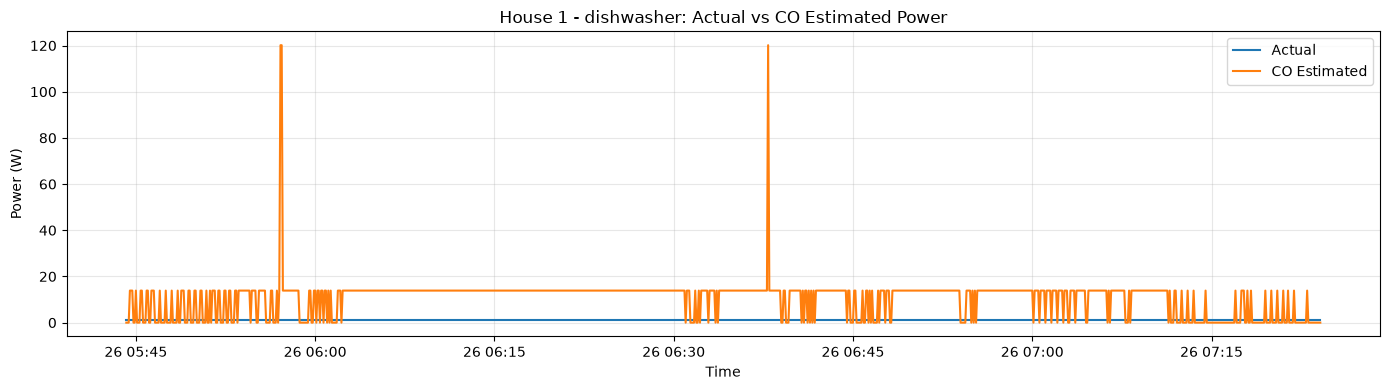

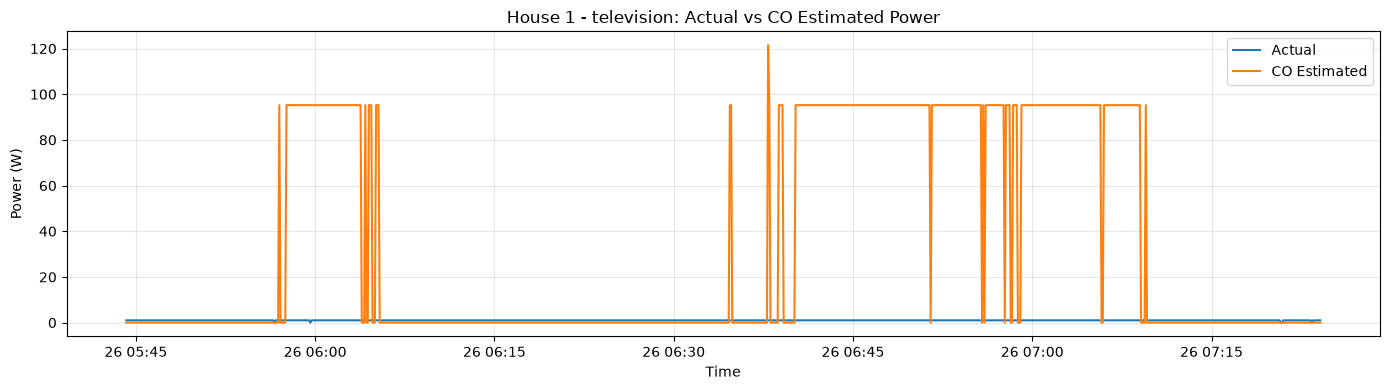

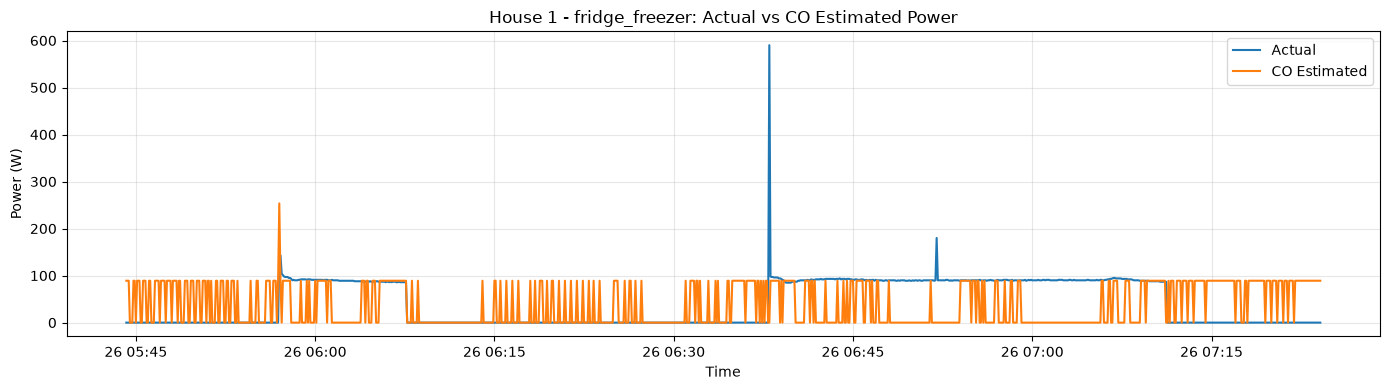

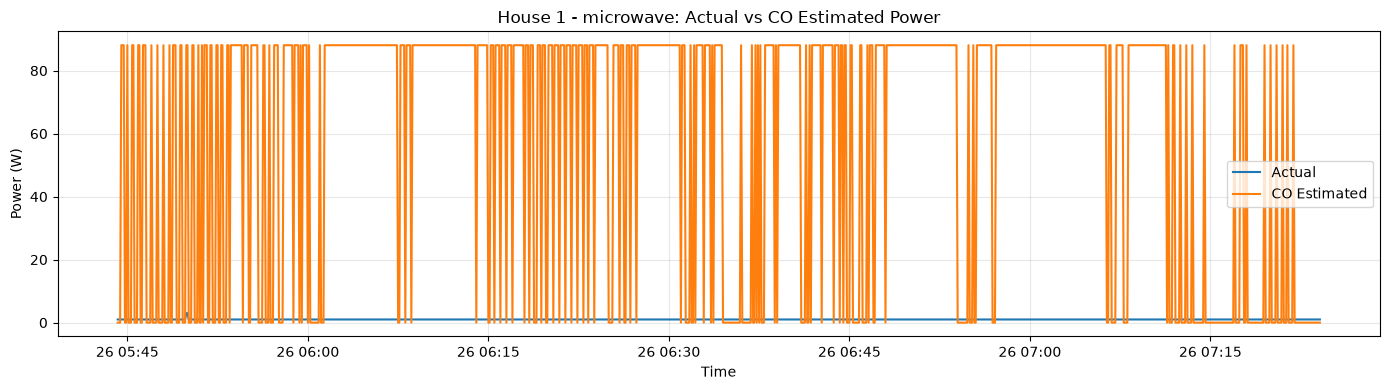

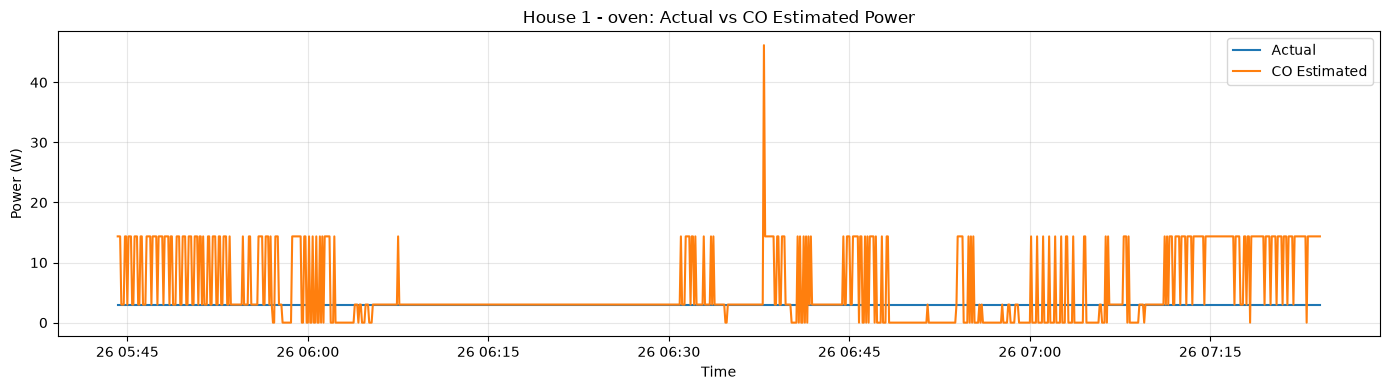


House 2


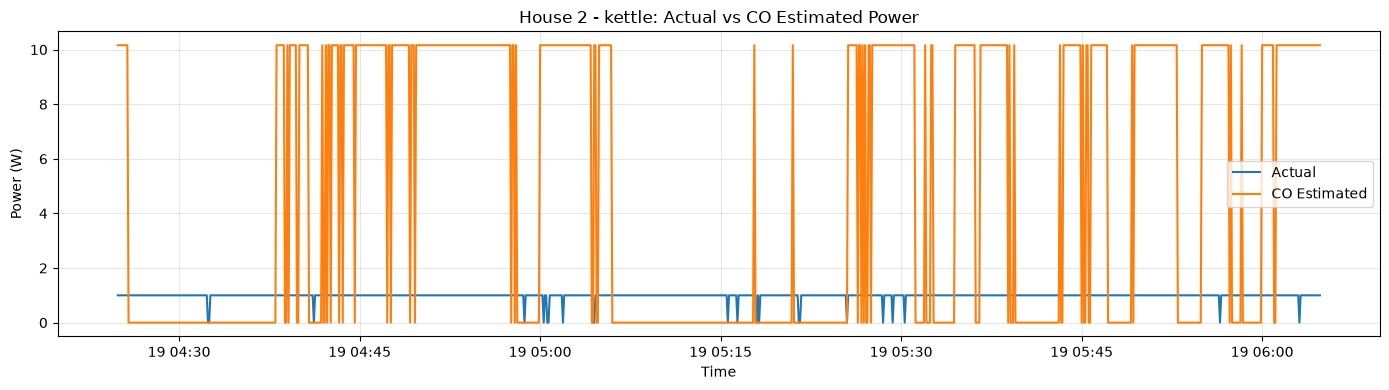

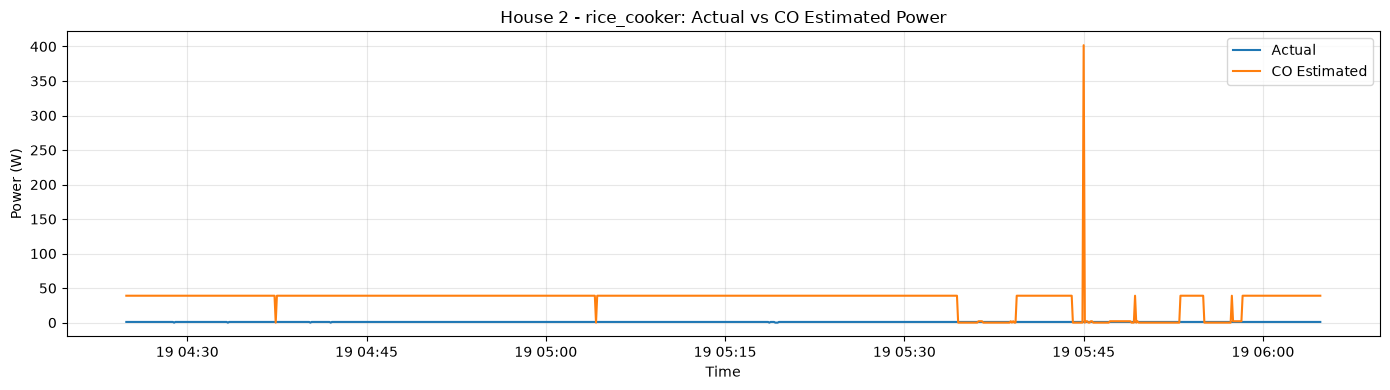

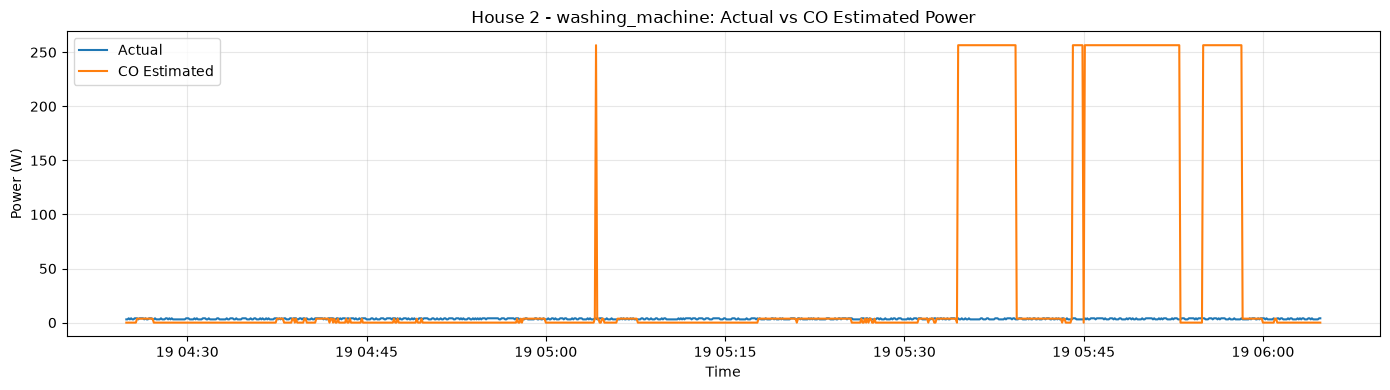

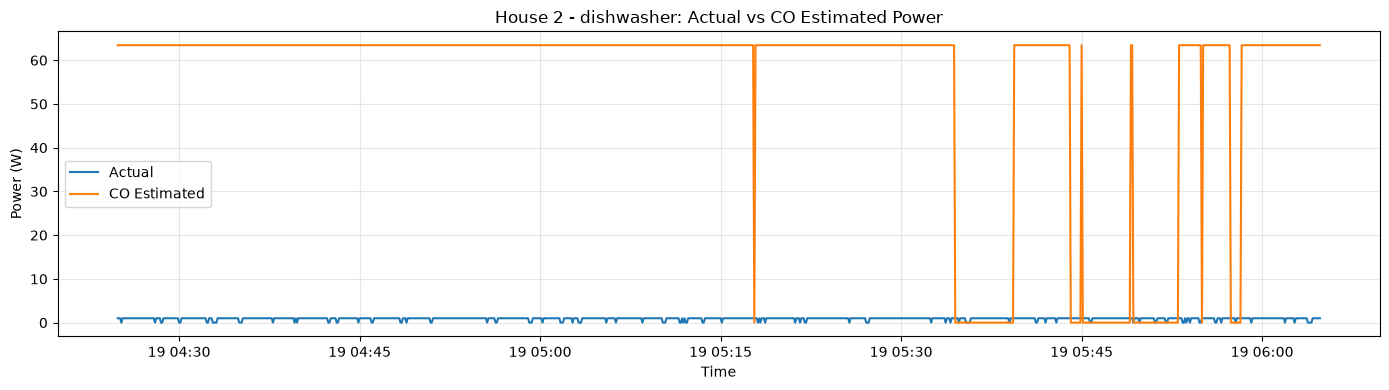

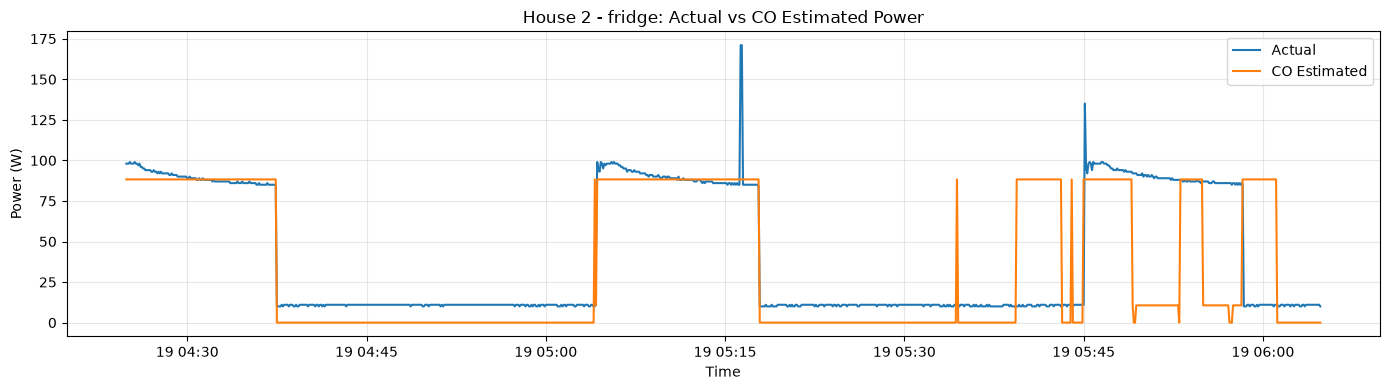


House 5


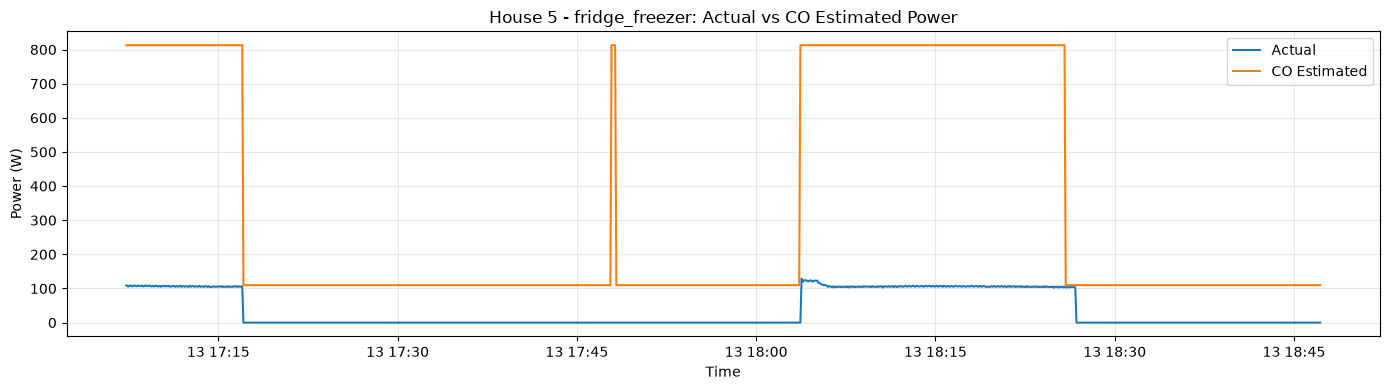

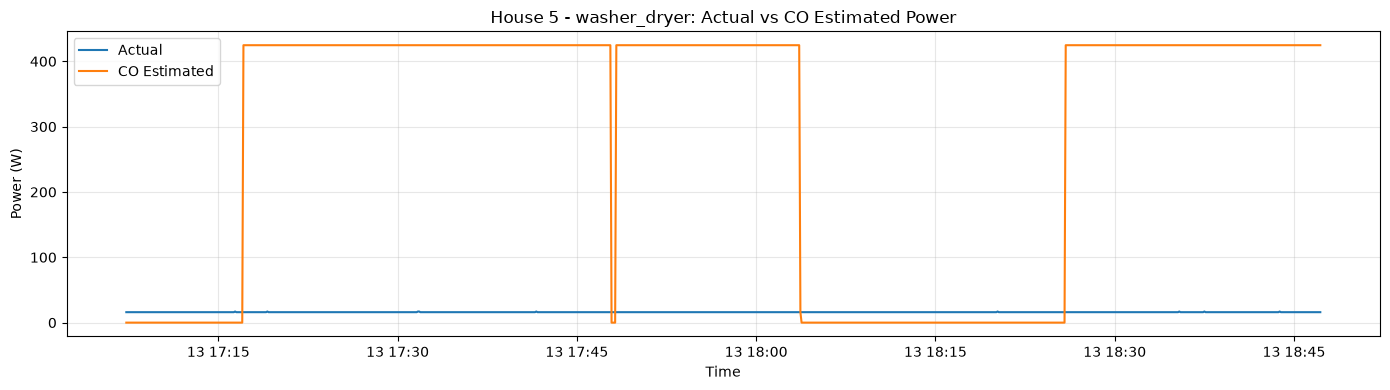

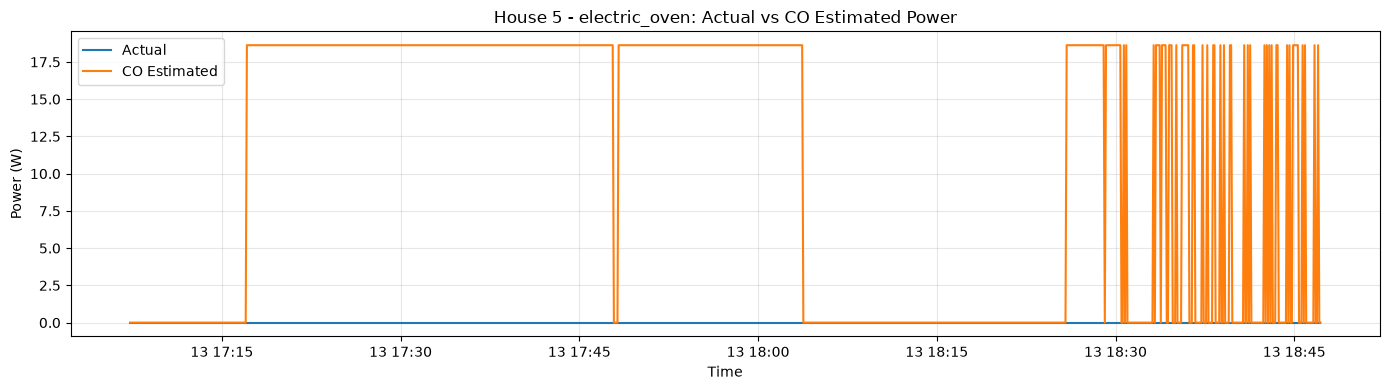

In [40]:
import matplotlib.pyplot as plt

# Number of test samples to visualize
PLOT_SAMPLES = 1000

print("Generating actual vs CO-estimated power plots")
print("=" * 75)

for house_id in CO_HOUSES:

    test_data = co_test_data[house_id]
    predictions = co_test_estimates[house_id]

    appliances = CO_APPLIANCES_BY_HOUSE[house_id]

    print(f"\nHouse {house_id}")

    for appliance in appliances:

        actual = test_data[appliance].iloc[:PLOT_SAMPLES]
        predicted = predictions[appliance].iloc[:PLOT_SAMPLES]

        plt.figure(figsize=(14, 4))

        plt.plot(
            actual.index,
            actual.values,
            label="Actual"
        )

        plt.plot(
            predicted.index,
            predicted.values,
            label="CO Estimated"
        )

        plt.title(
            f"House {house_id} - {appliance}: "
            "Actual vs CO Estimated Power"
        )

        plt.xlabel("Time")
        plt.ylabel("Power (W)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [41]:
# Compare actual and estimated aggregate energy for each appliance

energy_comparison = []

print("CO Aggregate Energy Comparison")
print("=" * 85)

for house_id in CO_HOUSES:

    test_data = co_test_data[house_id]
    predictions = co_test_estimates[house_id]

    for appliance in CO_APPLIANCES_BY_HOUSE[house_id]:

        actual = test_data[appliance].to_numpy(dtype=np.float64)
        predicted = predictions[appliance].to_numpy(dtype=np.float64)

        actual_energy = actual.sum()
        predicted_energy = predicted.sum()

        energy_error_percent = (
            abs(predicted_energy - actual_energy)
            / actual_energy
        ) * 100 if actual_energy > 0 else np.nan

        energy_comparison.append({
            "house": house_id,
            "appliance": appliance,
            "actual_energy_Wh": actual_energy * SAMPLE_PERIOD / 3600,
            "estimated_energy_Wh": predicted_energy * SAMPLE_PERIOD / 3600,
            "energy_error_percent": energy_error_percent
        })

energy_comparison_df = pd.DataFrame(energy_comparison)

print(
    energy_comparison_df.round({
        "actual_energy_Wh": 2,
        "estimated_energy_Wh": 2,
        "energy_error_percent": 2
    }).to_string(index=False)
)

CO Aggregate Energy Comparison
 house       appliance  actual_energy_Wh  estimated_energy_Wh  energy_error_percent
     1      dishwasher         296077.41            566929.16                 91.48
     1      television         123802.09            633191.05                411.45
     1  fridge_freezer         280279.82            810009.87                189.00
     1       microwave          29902.77            505606.13               1590.83
     1            oven          26932.22            116097.03                331.07
     2          kettle          10019.34             11748.72                 17.26
     2     rice_cooker           1669.22             24198.75               1349.71
     2 washing_machine           6393.55             36180.41                465.89
     2      dishwasher          20621.72             32077.34                 55.55
     2          fridge          20017.05             34120.12                 70.46
     5  fridge_freezer          23651.11     

In [42]:
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

co_metrics_path = RESULTS_DIR / "co_metrics.csv"
co_energy_path = RESULTS_DIR / "co_energy_comparison.csv"

co_metrics_df.to_csv(co_metrics_path, index=False)
energy_comparison_df.to_csv(co_energy_path, index=False)

print("CO evaluation results saved successfully.")
print(f"Metrics file          : {co_metrics_path}")
print(f"Energy comparison file: {co_energy_path}")

CO evaluation results saved successfully.
Metrics file          : ..\results\co_metrics.csv
Energy comparison file: ..\results\co_energy_comparison.csv
